In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [ ]:
np.random.seed(0)

In [ ]:
num_customer = 100000

data = {
    "Customer_ID": np.random.choice(np.arange(100000, 999999), size=num_customer, replace=False),
    "Age": np.random.randint(18,71, size=num_customer),
    "Gender": np.random.choice(["Male","Female"], size=num_customer),
    "Tenure": np.random.randint(1,11, size=num_customer),
    "Balance": np.random.randint(0,200000, size=num_customer),
    "Credict_Score": np.random.randint(300,901, size=num_customer),
    "Estimated_Salary": np.random.randint(10000,150000, size=num_customer),
    "Number_Of_Products": np.random.randint(1,5, size=num_customer),
    "isActiveMember": np.random.choice(["Yes","No"], size=num_customer),
    "Chrun": np.random.randint(0,2, size=num_customer)
}

df = pd.DataFrame(data)
df

,Customer_ID,Age,Gender,Tenure,Balance,Credict_Score,Estimated_Salary,Number_Of_Products,isActiveMember,Chrun
0,135335,43,Female,3,29800,778,15705,2,No,1
1,999406,30,Male,10,67527,778,73881,1,Yes,0
2,151672,42,Female,4,87190,447,97718,1,No,1
3,750699,45,Male,4,71930,604,79999,1,Yes,1
4,781297,24,Female,4,196784,806,78448,3,Yes,1
...,...,...,...,...,...,...,...,...,...,...
99995,176433,41,Female,8,174695,764,100218,4,Yes,0
99996,289591,21,Female,9,53352,674,88669,3,Yes,0
99997,411772,29,Male,1,133759,397,66765,1,Yes,1
99998,503025,49,Male,8,55375,757,144797,4,No,1


In [ ]:
print("Mean:\n")
print(df[["Balance", "Estimated_Salary", "Credict_Score"]].mean())

Mean:

Balance             99538.44453
Estimated_Salary    79822.77489
Credict_Score         599.36602
dtype: float64


In [ ]:
print("Median:\n")
print(df[["Balance", "Estimated_Salary", "Credict_Score"]].median())

Median:

Balance             99564.5
Estimated_Salary    79772.0
Credict_Score         599.0
dtype: float64


In [ ]:
print("Mode:\n")
print(df[["Balance", "Estimated_Salary", "Credict_Score"]].mode().iloc[0])

Mode:

Balance             45187.0
Estimated_Salary    13949.0
Credict_Score         701.0
Name: 0, dtype: float64


In [ ]:
print("Standard Deviation:\n")
print(df[["Balance", "Estimated_Salary", "Credict_Score"]].std())

Standard Deviation:

Balance             57711.934102
Estimated_Salary    40358.684069
Credict_Score         173.246623
dtype: float64


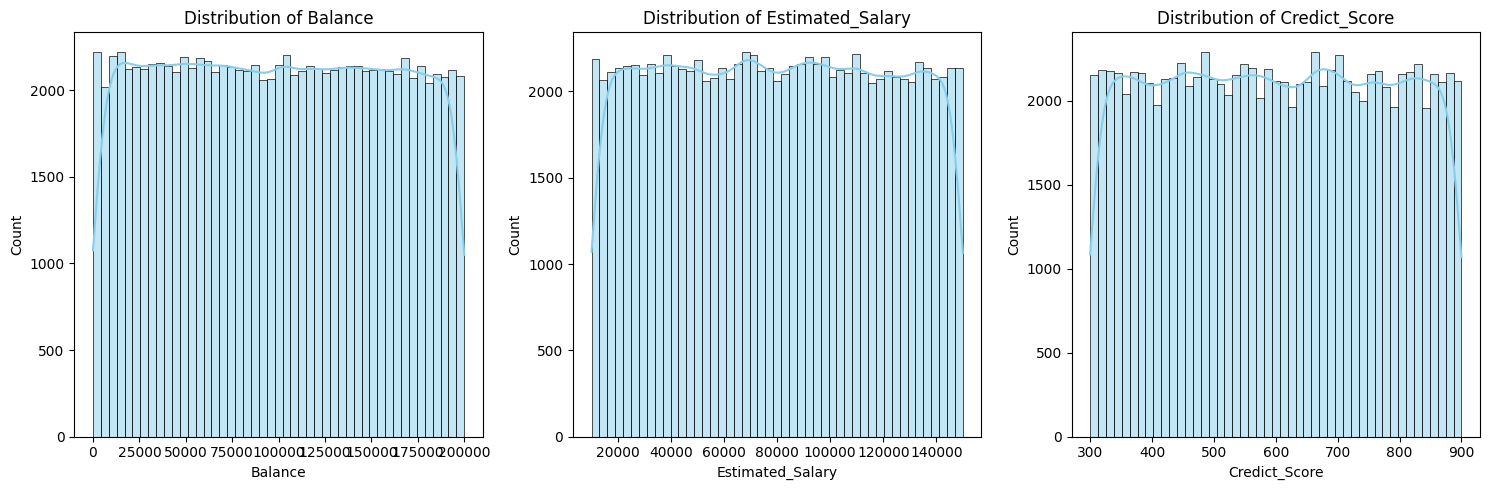

In [ ]:
plt.figure(figsize=(15, 5))

values = ["Balance", "Estimated_Salary", "Credict_Score"]

for index, value in enumerate(values, 1):
    plt.subplot(1, 3, index)
    sns.histplot(df[value], kde=True, color='skyblue')
    plt.title(f'Distribution of {value}')

plt.tight_layout()
plt.show()

Churn Rate by Gender:
Gender
Female    0.497447
Male      0.504844
Name: Chrun, dtype: float64


/tmp/ipykernel_4845/3260770506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Chrun', data=df, palette='magma')


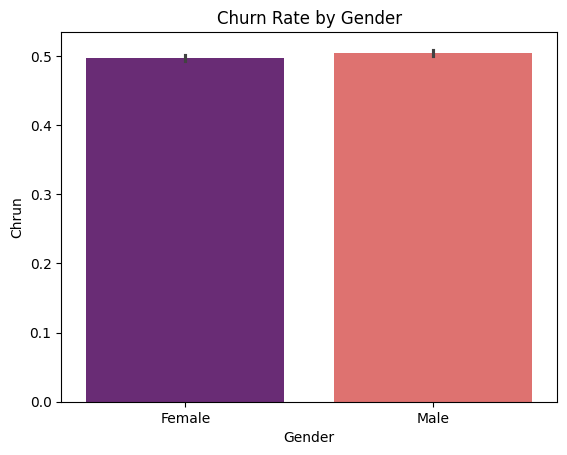

In [ ]:
print("Churn Rate by Gender:")
print(df.groupby('Gender')['Chrun'].mean())
sns.barplot(x='Gender', y='Chrun', data=df, palette='magma')
plt.title('Churn Rate by Gender')
plt.show()

Average Values by Churn Status:
            Balance  Estimated_Salary  Credict_Score        Age
Chrun                                                          
0      99770.993766      79732.448351     599.465290  43.949203
1      99306.962566      79912.686880     599.267205  43.974219


/tmp/ipykernel_4845/2709392137.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Chrun', y=col, data=df, palette='Set2')
/tmp/ipykernel_4845/2709392137.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Chrun', y=col, data=df, palette='Set2')
/tmp/ipykernel_4845/2709392137.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Chrun', y=col, data=df, palette='Set2')


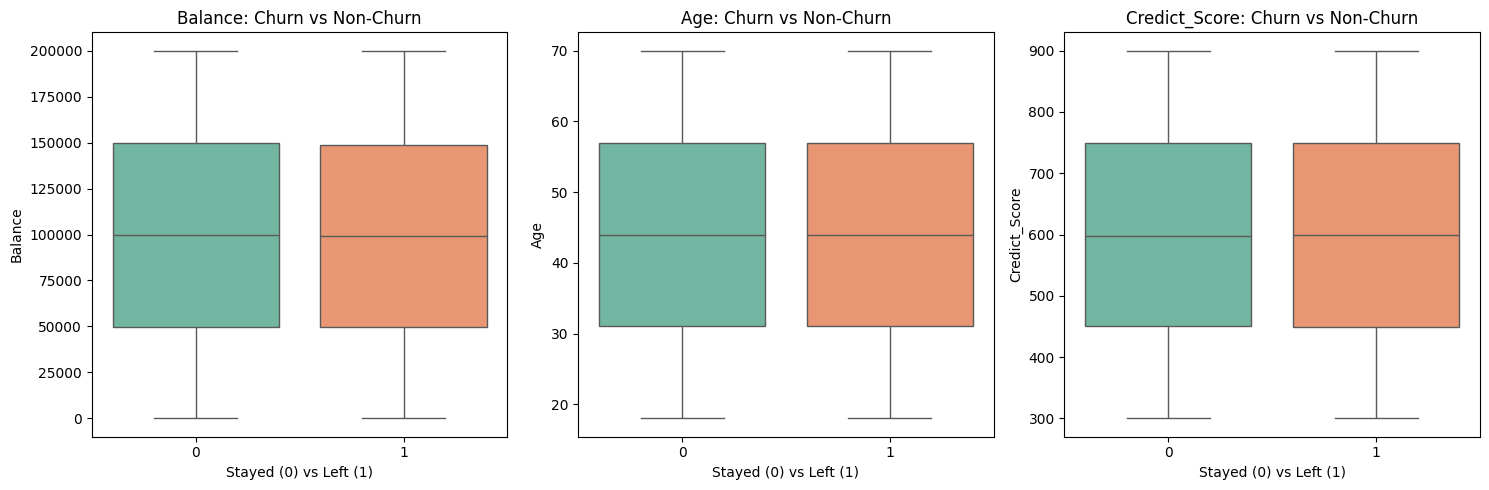

In [ ]:
comparison = df.groupby('Chrun')[["Balance", "Estimated_Salary", "Credict_Score", "Age"]].mean()
print("Average Values by Churn Status:")
print(comparison)

plt.figure(figsize=(15, 5))

features_to_compare = ["Balance", "Age", "Credict_Score"]

for i, col in enumerate(features_to_compare, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Chrun', y=col, data=df, palette='Set2')
    plt.title(f'{col}: Churn vs Non-Churn')
    plt.xlabel('Stayed (0) vs Left (1)')

plt.tight_layout()
plt.show()

Churn Rate by Age Group:
Age_Group
Young (18-30)          0.498974
Middle-Aged (31-45)    0.502610
Senior (46-60)         0.501040
Elderly (60+)          0.501734
Name: Chrun, dtype: float64


/tmp/ipykernel_4845/744886577.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('Age_Group')['Chrun'].mean()
/tmp/ipykernel_4845/744886577.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_churn.index, y=age_churn.values, palette='viridis')


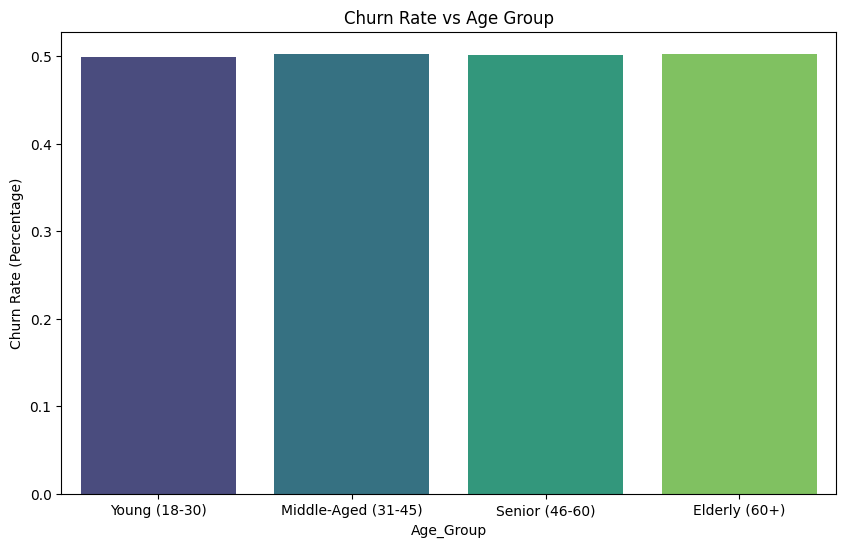

In [ ]:
bins = [18, 30, 45, 60, 71]
labels = ['Young (18-30)', 'Middle-Aged (31-45)', 'Senior (46-60)', 'Elderly (60+)']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_churn = df.groupby('Age_Group')['Chrun'].mean()
print("Churn Rate by Age Group:")
print(age_churn)

plt.figure(figsize=(10, 6))
sns.barplot(x=age_churn.index, y=age_churn.values, palette='viridis')
plt.title('Churn Rate vs Age Group')
plt.ylabel('Churn Rate (Percentage)')
plt.show()

Churn Rate by Gender:
Gender
Female    0.497447
Male      0.504844
Name: Chrun, dtype: float64


/tmp/ipykernel_4845/1651886832.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_churn.index, y=gender_churn.values, palette='magma')


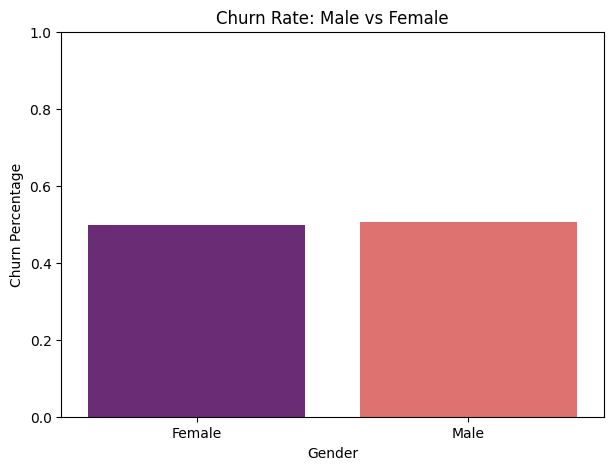

In [ ]:
gender_churn = df.groupby('Gender')['Chrun'].mean()
print("Churn Rate by Gender:")
print(gender_churn)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_churn.index, y=gender_churn.values, palette='magma')
plt.title('Churn Rate: Male vs Female')
plt.ylabel('Churn Percentage')
plt.ylim(0, 1)
plt.show()

Churn Rate by Activity Status:
isActiveMember
No     0.498559
Yes    0.503737
Name: Chrun, dtype: float64


/tmp/ipykernel_4845/3874157311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_churn.index, y=activity_churn.values, palette='viridis')


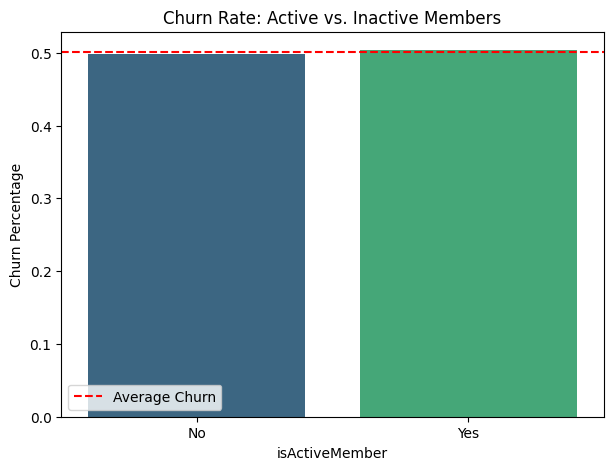

In [ ]:
activity_churn = df.groupby('isActiveMember')['Chrun'].mean()
print("Churn Rate by Activity Status:")
print(activity_churn)

plt.figure(figsize=(7, 5))
sns.barplot(x=activity_churn.index, y=activity_churn.values, palette='viridis')
plt.title('Churn Rate: Active vs. Inactive Members')
plt.ylabel('Churn Percentage')
plt.axhline(df['Chrun'].mean(), color='red', linestyle='--', label='Average Churn')
plt.legend()
plt.show()

Churn Rate by Number of Products:
Number_Of_Products
1    0.503318
2    0.498999
3    0.499960
4    0.502303
Name: Chrun, dtype: float64


/tmp/ipykernel_4845/4273150808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_churn.index, y=product_churn.values, palette='rocket')


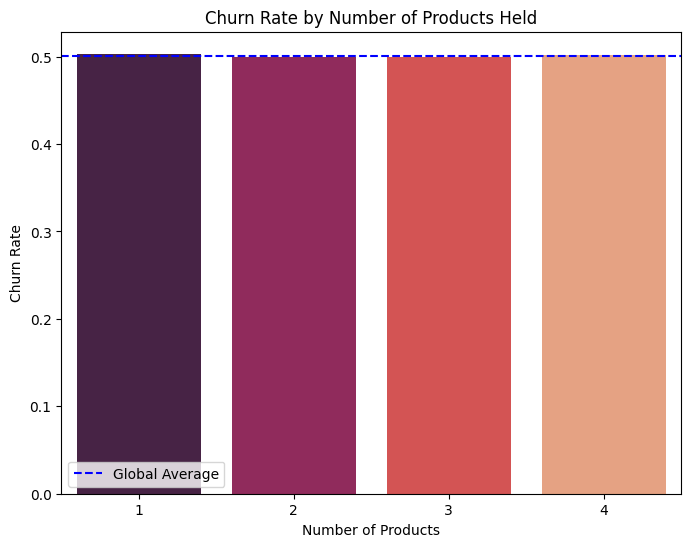

In [ ]:
product_churn = df.groupby('Number_Of_Products')['Chrun'].mean()
print("Churn Rate by Number of Products:")
print(product_churn)

plt.figure(figsize=(8, 6))
sns.barplot(x=product_churn.index, y=product_churn.values, palette='rocket')
plt.title('Churn Rate by Number of Products Held')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.axhline(df['Chrun'].mean(), color='blue', linestyle='--', label='Global Average')
plt.legend()
plt.show()

/tmp/ipykernel_4845/4144680209.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Bins', y='Chrun', data=df, palette='coolwarm')
/tmp/ipykernel_4845/4144680209.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Chrun', data=df, palette='magma')
/tmp/ipykernel_4845/4144680209.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='isActiveMember', y='Chrun', data=df, palette='viridis')
/tmp/ipykernel_4845/4144680209.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

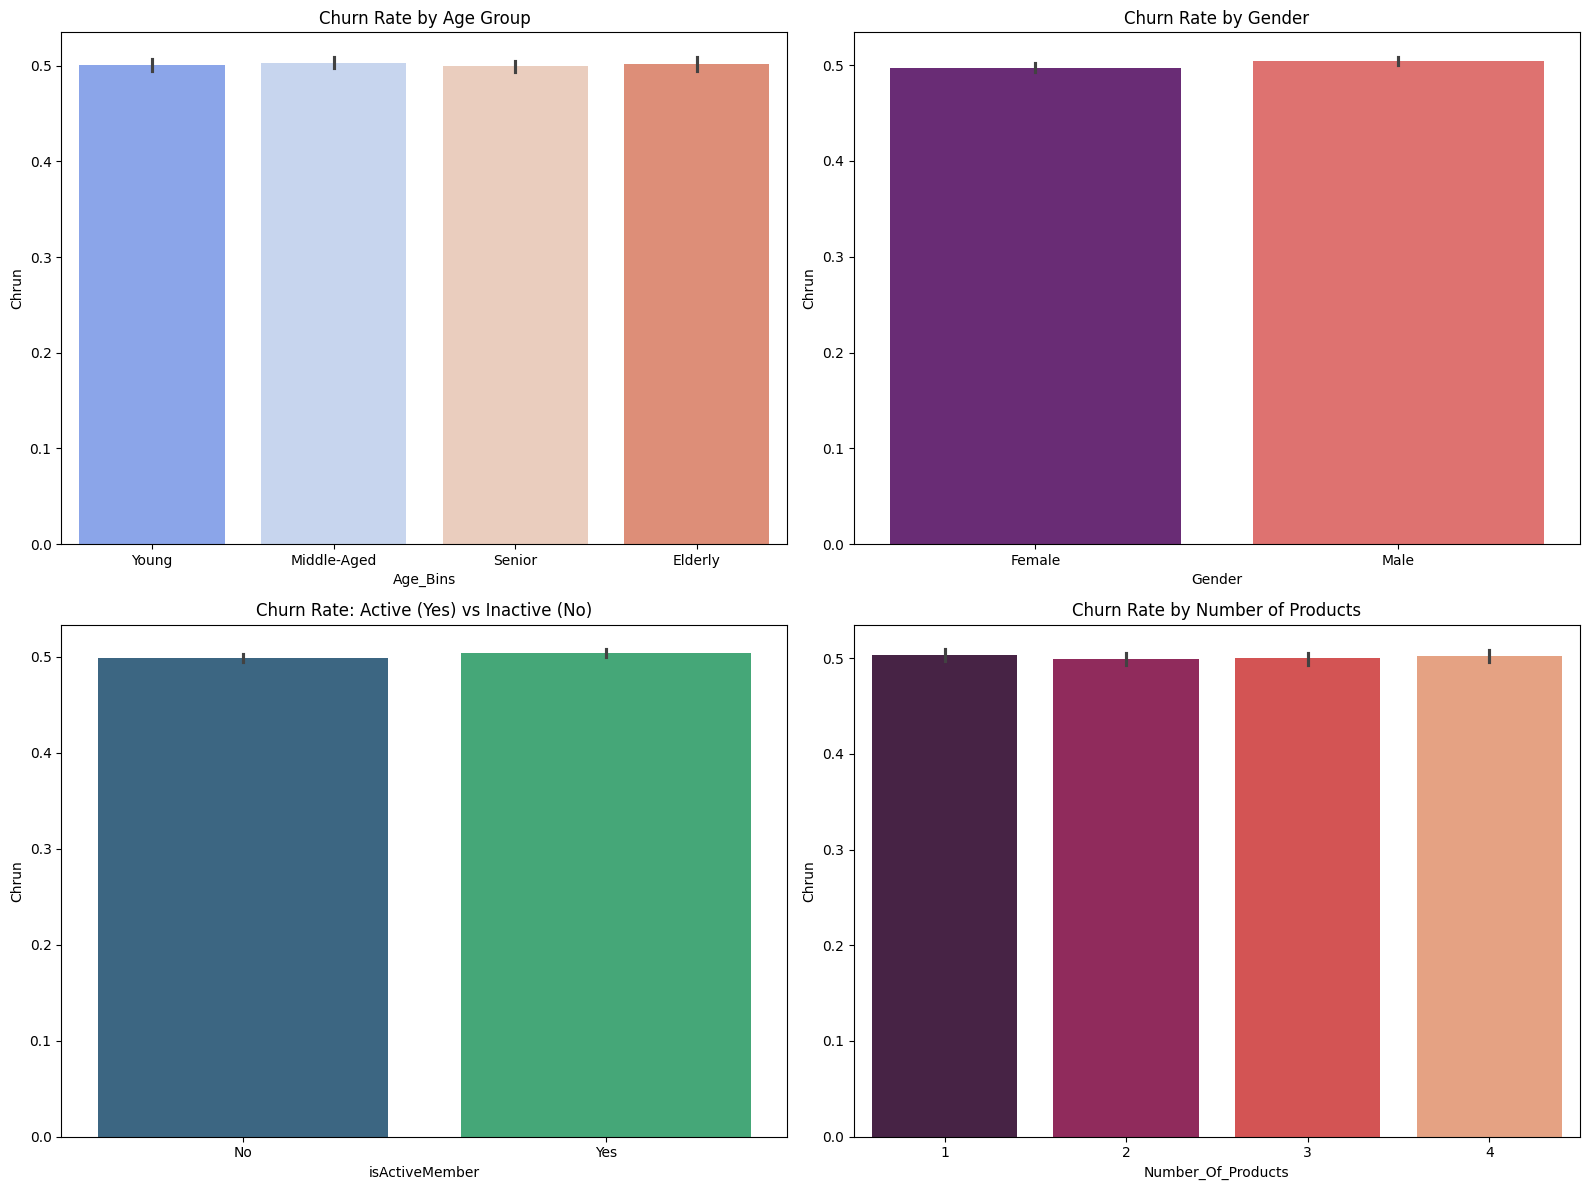

In [ ]:
df['Age_Bins'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 71], labels=['Young', 'Middle-Aged', 'Senior', 'Elderly'])

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.barplot(x='Age_Bins', y='Chrun', data=df, palette='coolwarm')
plt.title('Churn Rate by Age Group')

plt.subplot(2, 2, 2)
sns.barplot(x='Gender', y='Chrun', data=df, palette='magma')
plt.title('Churn Rate by Gender')

plt.subplot(2, 2, 3)
sns.barplot(x='isActiveMember', y='Chrun', data=df, palette='viridis')
plt.title('Churn Rate: Active (Yes) vs Inactive (No)')

plt.subplot(2, 2, 4)
sns.barplot(x='Number_Of_Products', y='Chrun', data=df, palette='rocket')
plt.title('Churn Rate by Number of Products')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4845/970126534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Chrun', y='Balance', data=df, palette='Set2')
/tmp/ipykernel_4845/970126534.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Chrun', y='Credict_Score', data=df, palette='pastel')
/tmp/ipykernel_4845/970126534.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette='magma')


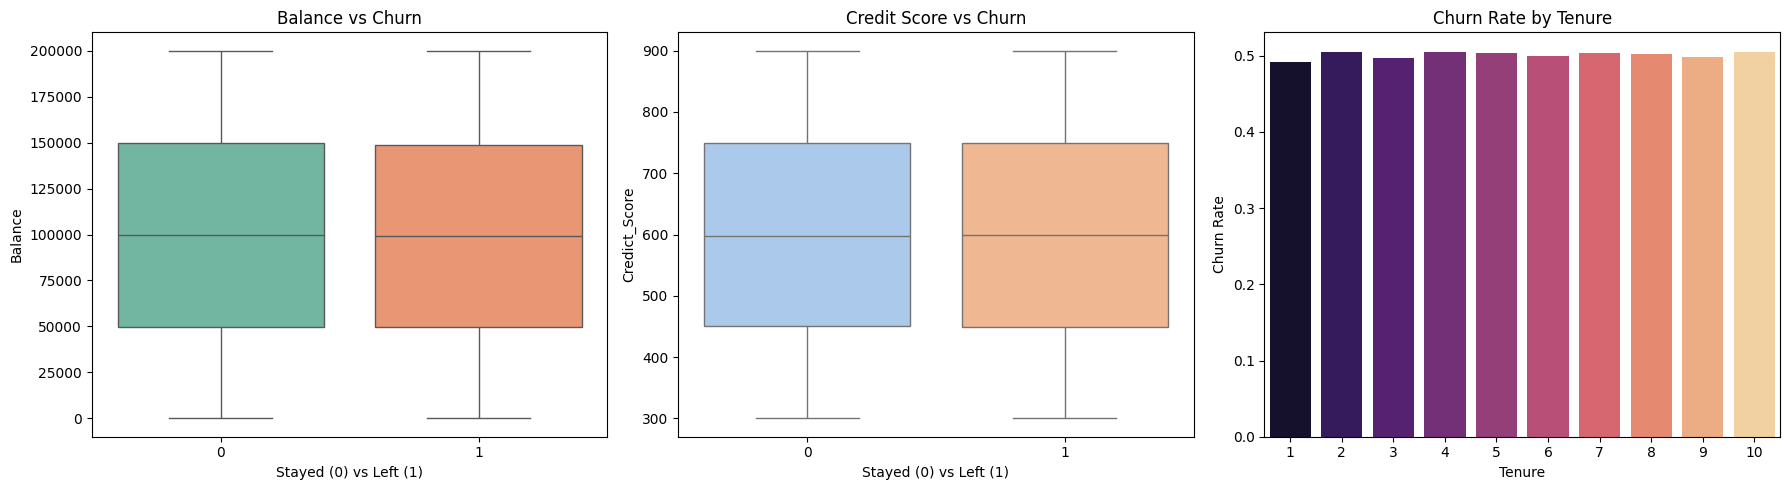

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Chrun', y='Balance', data=df, palette='Set2')
plt.title('Balance vs Churn')
plt.xlabel('Stayed (0) vs Left (1)')

plt.subplot(1, 3, 2)
sns.boxplot(x='Chrun', y='Credict_Score', data=df, palette='pastel')
plt.title('Credit Score vs Churn')
plt.xlabel('Stayed (0) vs Left (1)')

plt.subplot(1, 3, 3)
tenure_churn = df.groupby('Tenure')['Chrun'].mean()
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette='magma')
plt.title('Churn Rate by Tenure')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()

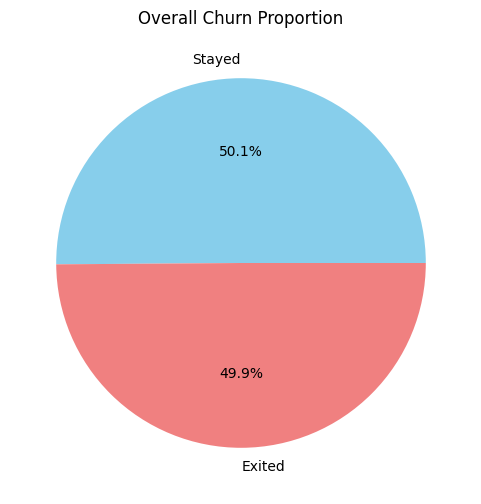

In [ ]:
plt.figure(figsize=(6, 6))
df['Chrun'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], labels=['Stayed', 'Exited'])
plt.title('Overall Churn Proportion')
plt.ylabel('')
plt.show()

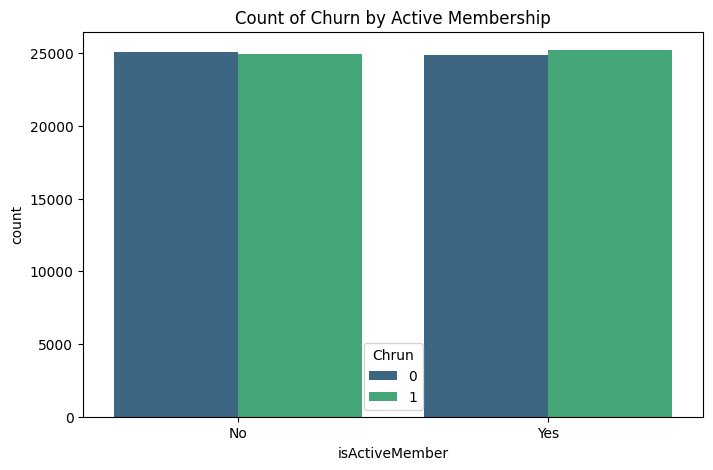

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='isActiveMember', hue='Chrun', data=df, palette='viridis')
plt.title('Count of Churn by Active Membership')
plt.show()

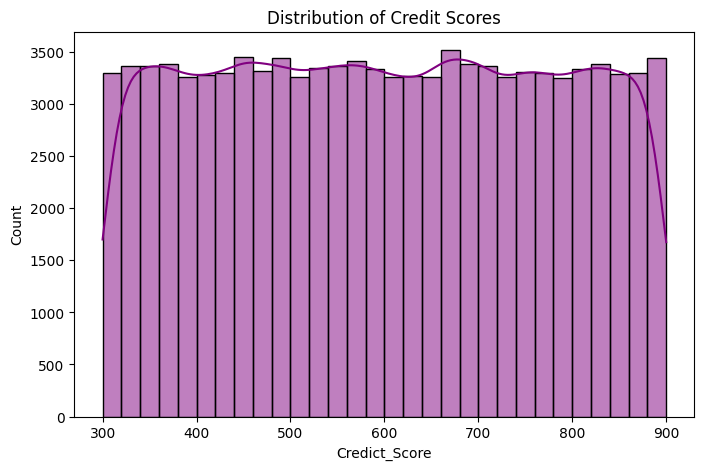

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Credict_Score'], bins=30, kde=True, color='purple')
plt.title('Distribution of Credit Scores')
plt.show()

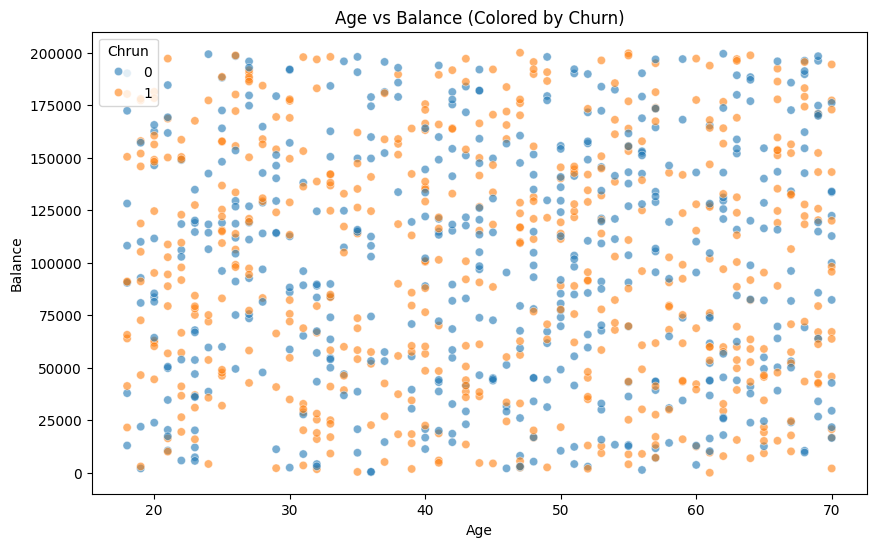

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Balance', hue='Chrun', data=df.sample(1000), alpha=0.6)
plt.title('Age vs Balance (Colored by Churn)')
plt.show()

/tmp/ipykernel_4845/1379855012.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Chrun', y='Estimated_Salary', data=df, palette='Set3')


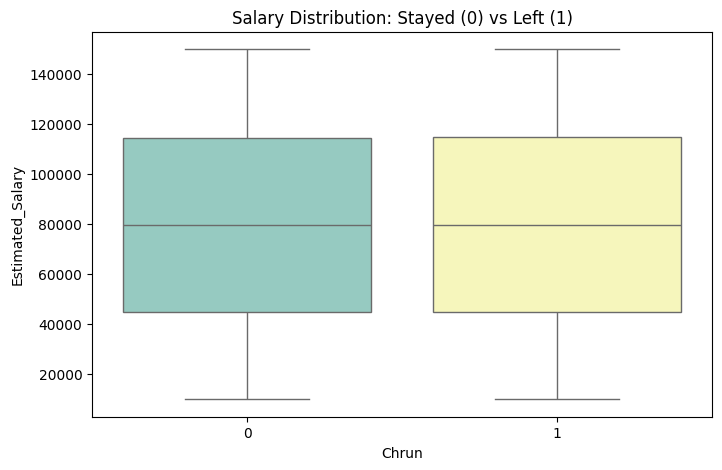

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Chrun', y='Estimated_Salary', data=df, palette='Set3')
plt.title('Salary Distribution: Stayed (0) vs Left (1)')
plt.show()

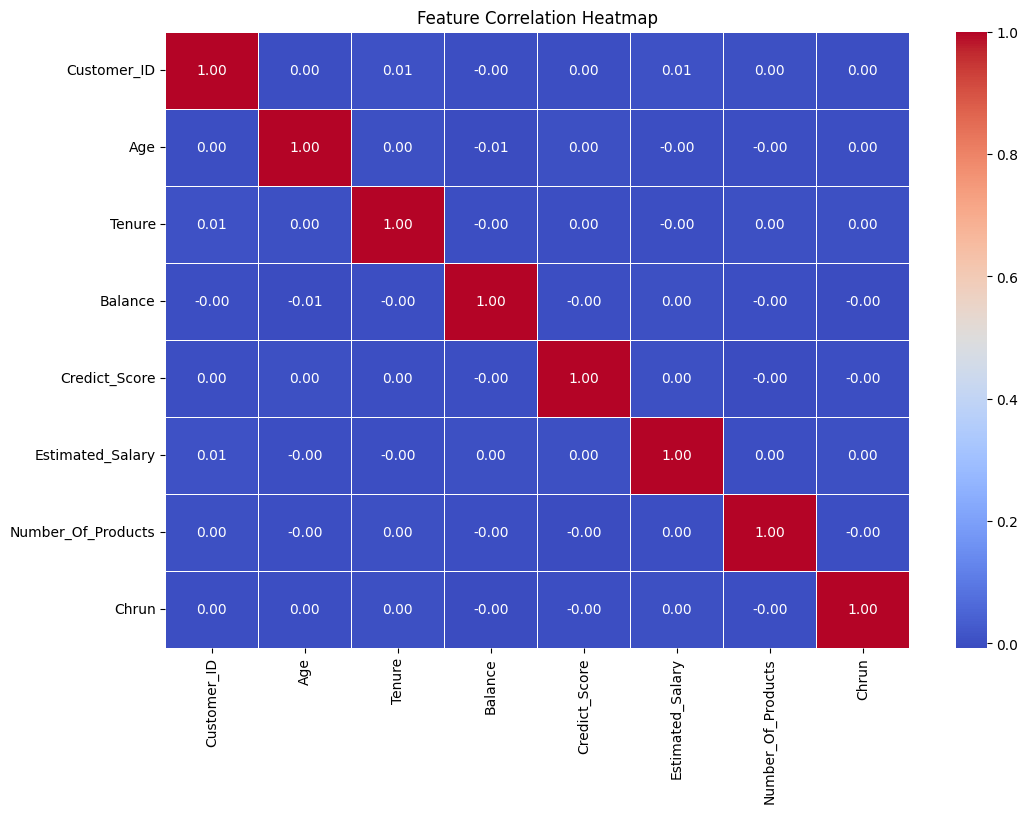

In [ ]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()